In [1]:
!hostname

n21.clstr


In [2]:
import xarray as xr
import os
import glob
import geopandas as gpd
import pandas as pd
import numpy as np
from scipy.stats import linregress
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import HTML
from matplotlib.ticker import MaxNLocator
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm


ros_colorbar = LinearSegmentedColormap.from_list('ros', [
    '#4B2D1A',  # deep brown
    '#7A4A22',  # warm brown
    '#B5743C',  # lighter brown
    '#E3C7A3',  # tan
    #'#F7F7F7',  # near-white (neutral midpoint!)
    '#CFE8F3',  # very light blue
    '#9ECAE1',  # soft blue
    '#5DA5DA',  # medium blue
    '#2B7BBA',  # deeper blue
    '#1B4F72'   # muted dark blue
])

swe_colorbar= 'BrBG'
rain_colorbar = 'BrBG'

import cmocean
cmocean_options=cmocean.cm.cmap_d;
oceanrain=cmocean_options['rain']

<Axes: >

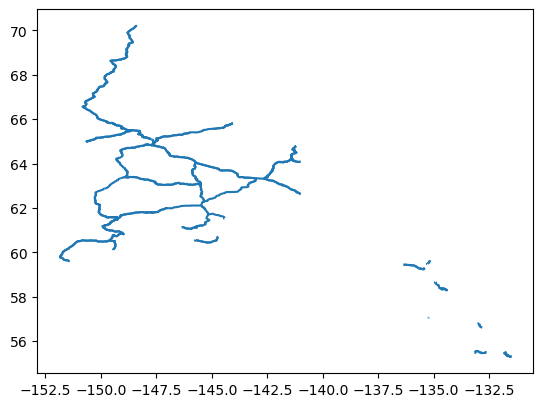

In [3]:
mainroads = gpd.read_file("/center1/DYNDOWN/phutton5/ROS/boundaries/tl_2024_02_prisecroads.shp")
mainroads = mainroads.set_crs("EPSG:3338", allow_override=True)
#mainroads = mainroads.to_crs("EPSG:4326")
mainroads.plot()

In [3]:
roadsystem = gpd.read_file("/center1/DYNDOWN/phutton5/ROS/boundaries/Roads_AKDOT.shp")
roadsystem = roadsystem.set_crs("EPSG:3338", allow_override=True)
roadsystem = roadsystem.to_crs("EPSG:4326")

/home/phutton5/miniconda3/envs/dyndown/lib/python3.11/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


In [4]:
threshold_rain=0.01
path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files'
monthly=xr.open_dataset(path+'/theilsen_trend_mannkndall_monthly_1950_2022.nc')
monthly

<xarray.Dataset> Size: 1GB
Dimensions:                                  (month: 5, south_north: 450,
                                              west_east: 420, interp_level: 3)
Coordinates:
  * month                                    (month) int64 40B 11 12 1 2 3
    XLAT                                     (south_north, west_east) float32 756kB ...
    XLONG                                    (south_north, west_east) float32 756kB ...
    month_name                               (month) <U3 60B ...
  * interp_level                             (interp_level) float64 24B 850.0...
Dimensions without coordinates: south_north, west_east
Data variables: (12/104)
    ros_tally_slope_theilsen                 (month, south_north, west_east) float64 8MB ...
    ros_tally_intercept_theilsen             (month, south_north, west_east) float64 8MB ...
    ros_tally_low_slope_theilsen             (month, south_north, west_east) float64 8MB ...
    ros_tally_high_slope_theilsen            (month, south_north, west_east) float64 8MB ...
    ros_counts_slope_theilsen                (month, south_north, west_east) float64 8MB ...
    ros_counts_intercept_theilsen            (month, south_north, west_east) float64 8MB ...
    ...                                       ...
    temp_levels_avg_S_mannkendall            (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_avg_var_S_mannkendall        (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_tau_mannkendall      (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_p_value_mannkendall  (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_S_mannkendall        (month, interp_level, south_north, west_east) float64 23MB ...
    temp_levels_ros_avg_var_S_mannkendall    (month, interp_level, south_north, west_east) float64 23MB ...

In [5]:
seasonal=xr.open_dataset(path+'/theilsen_trend_mannkndall_seasonal_1950_2022.nc')
seasonal

<xarray.Dataset> Size: 207MB
Dimensions:                                  (south_north: 450, west_east: 420,
                                              interp_level: 3)
Coordinates:
    XLAT                                     (south_north, west_east) float32 756kB ...
    XLONG                                    (south_north, west_east) float32 756kB ...
  * interp_level                             (interp_level) float64 24B 850.0...
Dimensions without coordinates: south_north, west_east
Data variables: (12/104)
    ros_tally_slope_theilsen                 (south_north, west_east) float64 2MB ...
    ros_tally_intercept_theilsen             (south_north, west_east) float64 2MB ...
    ros_tally_low_slope_theilsen             (south_north, west_east) float64 2MB ...
    ros_tally_high_slope_theilsen            (south_north, west_east) float64 2MB ...
    ros_counts_slope_theilsen                (south_north, west_east) float64 2MB ...
    ros_counts_intercept_theilsen            (south_north, west_east) float64 2MB ...
    ...                                       ...
    temp_levels_avg_S_mannkendall            (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_avg_var_S_mannkendall        (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_ros_avg_tau_mannkendall      (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_ros_avg_p_value_mannkendall  (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_ros_avg_S_mannkendall        (interp_level, south_north, west_east) float64 5MB ...
    temp_levels_ros_avg_var_S_mannkendall    (interp_level, south_north, west_east) float64 5MB ...

In [6]:
def plot_row(ax_row, datasets):
    for ax, (data, pvals, title) in zip(ax_row, datasets):
        pcm = ax.pcolormesh(
            lon, lat, data,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            shading='auto',
            transform=ccrs.PlateCarree()
        )

        sig = pvals < 0.05

        ax.contourf(
            lon, lat, sig,
            levels=[0.5, 1.5],
            colors='none',
            hatches=['...'],
            transform=ccrs.PlateCarree()
        )

        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.add_feature(cfeature.BORDERS, zorder=8)
        ax.add_feature(cfeature.COASTLINE, zorder=8)
        ax.add_feature(cfeature.RIVERS, zorder=8)
        ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
        ax.set_aspect('equal')

    return pcm

In [7]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)
FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)
lat=seasonal['XLAT']
lon=seasonal['XLONG']

ANC_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
MATSU_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
KENAI_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Kenai Peninsula Borough']
BETHEL_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
ANC_boundary= borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']

rain_ros_avg,rain_ros_sum,T2_avg,T2_ros_avg

NOW LOOKING AT  THE PERCENT 

In [8]:
path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/'
compare=f'ROS_Monthly_*.nc'
file_list = sorted(glob.glob(os.path.join(path, compare)))
combined_ds=xr.open_mfdataset(file_list, combine='by_coords',engine='netcdf4')

os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')
#oceanmask_expanded = oceanmask.expand_dims(Time=data.Time)

combined_ds = combined_ds.where(oceanmask != 17)

lat=combined_ds['XLAT']
lon=combined_ds['XLONG']
monthlist=['November','December','January','February','March' ]
monthnumberlist=[11,12,1,2,3]

Percent per decade found here 
-

In [9]:
nov_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=11),axis=0)
dec_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=12),axis=0)
jan_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=1),axis=0)
feb_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=2),axis=0)
mar_ros_tally_avg=np.mean(combined_ds['ros_tally'].sel(month=3),axis=0)
seasonal_ros_tally_avg=np.mean(combined_ds['ros_tally'].sum(axis=1),axis=0)

nov_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=11),axis=0)
dec_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=12),axis=0)
jan_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=1),axis=0)
feb_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=2),axis=0)
mar_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sel(month=3),axis=0)
seasonal_ros_rain_sum_avg=np.mean(combined_ds['rain_ros_sum'].sum(axis=1),axis=0)

nov_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=11),axis=0)
dec_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=12),axis=0)
jan_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=1),axis=0)
feb_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=2),axis=0)
mar_rain_sum_avg=np.mean(combined_ds['rain_sum'].sel(month=3),axis=0)
seasonal_rain_sum_avg=np.mean(combined_ds['rain_sum'].sum(axis=1),axis=0)

nov_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=11),axis=0)
dec_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=12),axis=0)
jan_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=1),axis=0)
feb_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=2),axis=0)
mar_swe_avg=np.mean(combined_ds['swe_avg'].sel(month=3),axis=0)
seasonal_swe_avg=np.sum(combined_ds['swe_avg'],axis=1)
seasonal_swe_avg=np.mean(seasonal_swe_avg,axis=0)

nov_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=11),axis=0)
dec_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=12),axis=0)
jan_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=1),axis=0)
feb_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=2),axis=0)
mar_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=3),axis=0)
seasonal_t2_avg=np.mean(combined_ds['T2_avg'].sum(axis=1),axis=0)

nov_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=11),axis=0)
dec_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=12),axis=0)
jan_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=1),axis=0)
feb_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=2),axis=0)
mar_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=3),axis=0)
seasonal_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sum(axis=1),axis=0)


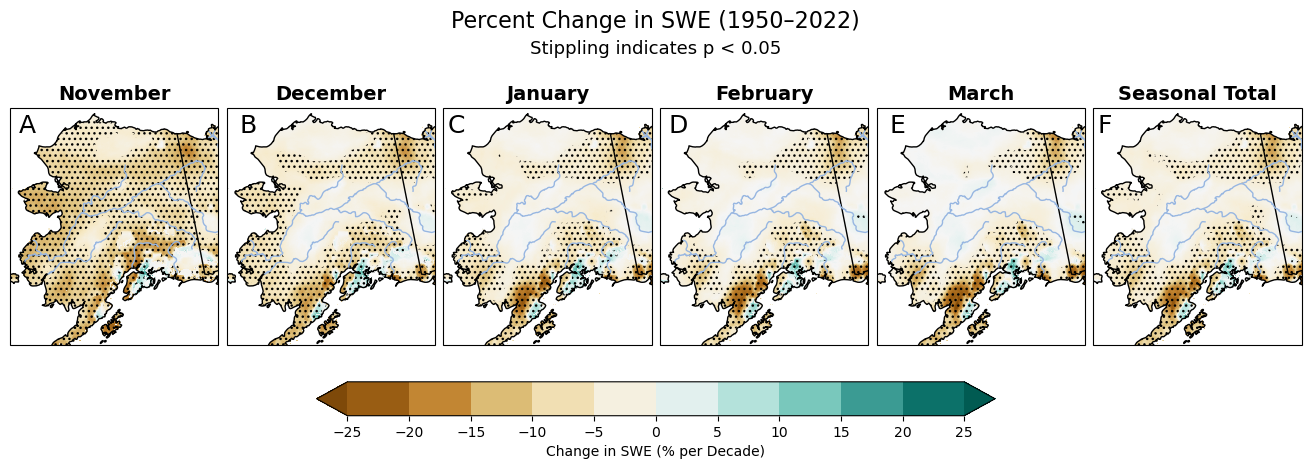

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)

vmin, vmax = -30,30


threshold=1
datasets = [
    (monthly['swe_avg_slope_theilsen'].sel(month=11)*10/nov_swe_avg.where(nov_swe_avg > threshold)*100 ,monthly['swe_avg_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['swe_avg_slope_theilsen'].sel(month=12)*10/dec_swe_avg.where(dec_swe_avg > threshold) *100 ,monthly['swe_avg_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['swe_avg_slope_theilsen'].sel(month=1)*10/jan_swe_avg.where(jan_swe_avg> threshold) *100,monthly['swe_avg_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['swe_avg_slope_theilsen'].sel(month=2)*10/feb_swe_avg.where(feb_swe_avg>threshold) *100,monthly['swe_avg_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['swe_avg_slope_theilsen'].sel(month=3)*10/mar_swe_avg.where(mar_swe_avg>threshold)*100,monthly['swe_avg_p_value_mannkendall'].sel(month=3), "March"),
    (seasonal['swe_avg_slope_theilsen']*10/seasonal_swe_avg.where(seasonal_swe_avg>threshold) *100,seasonal['swe_avg_p_value_mannkendall'],"Seasonal Total")]


levels = np.arange(-25, 30, 5)


for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap='BrBG',
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree())
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')

fig.suptitle("Percent Change in SWE (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Stippling indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs, boundaries=levels, orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label('Change in SWE (% per Decade)')
cbar.set_ticks(np.arange(-25,30, 5))
fig.text(0.01, 0.64, 'A', fontsize=18,  va='top', ha='left')
fig.text(0.18, 0.64, 'B', fontsize=18, va='top', ha='left')
fig.text(0.34, 0.64, 'C', fontsize=18, va='top', ha='left')
fig.text(0.51, 0.64, 'D', fontsize=18, va='top', ha='left')
fig.text(0.68, 0.64, 'E', fontsize=18, va='top', ha='left')
fig.text(0.84, 0.64, 'F', fontsize=18, va='top', ha='left')
fig.patch.set_alpha(0.0)
plt.show()

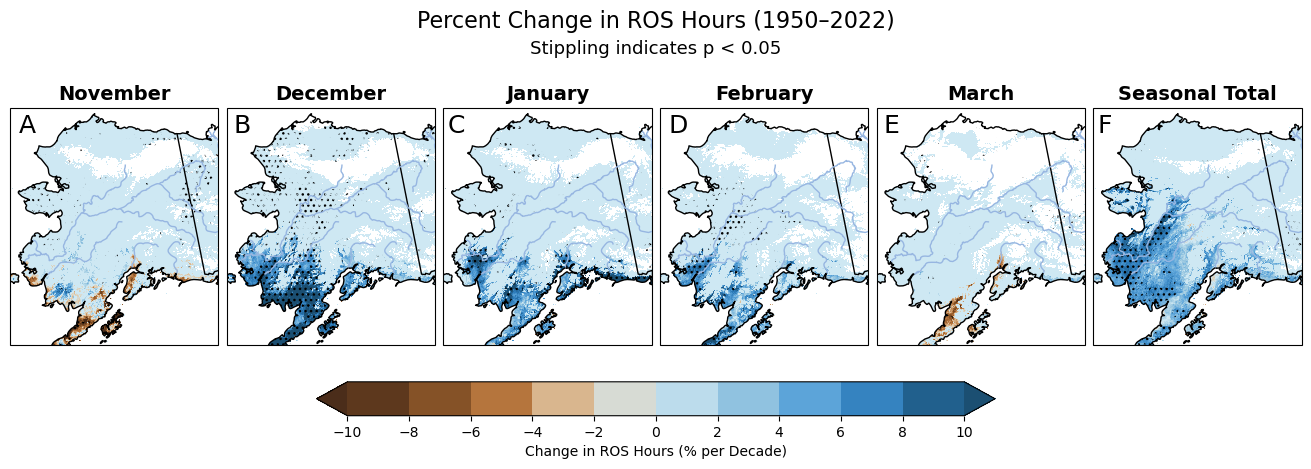

In [27]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10,12,2)
vmin, vmax = -10,10


#cmap=ros_colorbar
#cmap = 'coolwarm'
threshold=0.1
datasets = [
    (monthly['ros_tally_slope_theilsen'].sel(month=11)*10/nov_ros_tally_avg.where(nov_ros_tally_avg > threshold)*100 ,monthly['ros_tally_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['ros_tally_slope_theilsen'].sel(month=12)*10/dec_ros_tally_avg.where(dec_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['ros_tally_slope_theilsen'].sel(month=1)*10/jan_ros_tally_avg.where(jan_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['ros_tally_slope_theilsen'].sel(month=2)*10/feb_ros_tally_avg.where(feb_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['ros_tally_slope_theilsen'].sel(month=3)*10/mar_ros_tally_avg.where(mar_ros_tally_avg > threshold)*100,monthly['ros_tally_p_value_mannkendall'].sel(month=3), "March"),
    (seasonal['ros_tally_slope_theilsen']*10/seasonal_ros_tally_avg.where(seasonal_ros_tally_avg > threshold)*100,seasonal['ros_tally_p_value_mannkendall'],"Seasonal Total")]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap= ros_colorbar,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree())
    
    
    #ax.set_title(title)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')


fig.suptitle("Percent Change in ROS Hours (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Stippling indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs, boundaries=levels, orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Change in ROS Hours (% per Decade)')
cbar.set_ticks(levels)

fig.text(0.01, 0.64, 'A', fontsize=18,  va='top', ha='left')
fig.text(0.175, 0.64, 'B', fontsize=18, va='top', ha='left')
fig.text(0.34, 0.64, 'C', fontsize=18, va='top', ha='left')
fig.text(0.51, 0.64, 'D', fontsize=18, va='top', ha='left')
fig.text(0.675, 0.64, 'E', fontsize=18, va='top', ha='left')
fig.text(0.84, 0.64, 'F', fontsize=18, va='top', ha='left')


fig.patch.set_alpha(0.0)
plt.show()

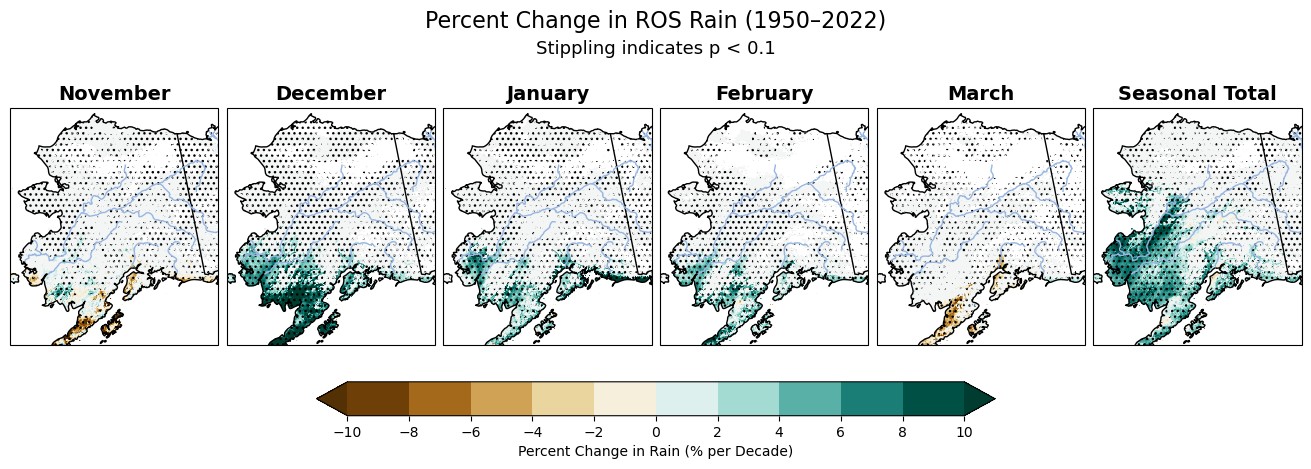

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10,10
cmap = rain_colorbar

threshold=0.1 

datasets = [
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=11)*10/nov_ros_rain_sum_avg.where(nov_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=12)*10/dec_ros_rain_sum_avg.where(dec_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=1)*10/jan_ros_rain_sum_avg.where(jan_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=2)*10/feb_ros_rain_sum_avg.where(feb_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=3)*10/mar_ros_rain_sum_avg.where(mar_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_ros_sum_slope_theilsen']*10/seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold)*100, seasonal['rain_ros_sum_p_value_mannkendall'], "Seasonal Total")
]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree()) #all
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree()) #fai
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree())  #anc
    #ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree()) #bethel
    ax.set_aspect('equal')

fig.suptitle("Percent Change in ROS Rain (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Stippling indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Percent Change in Rain (% per Decade)')
cbar.set_ticks(levels)

fig.patch.set_alpha(0.0)
plt.show()

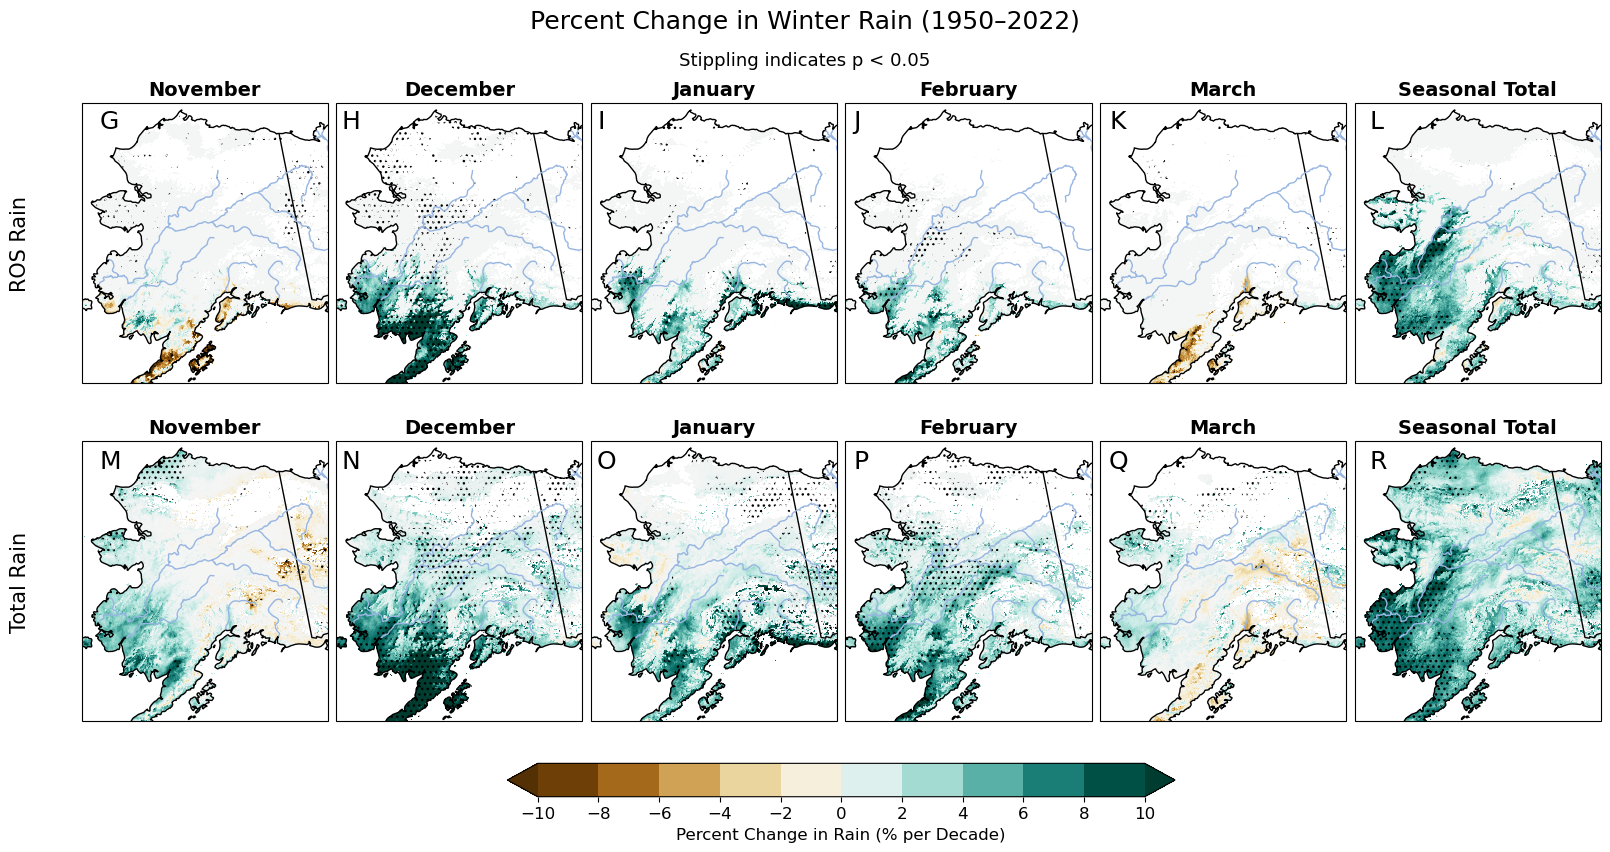

In [40]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))
}

fig, axs = plt.subplots(
    nrows=2, ncols=6,
    figsize=(16, 8),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10, 10
cmap = 'BrBG'

threshold_rain=0.254

ros_datasets = [
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=11)*10/nov_ros_rain_sum_avg.where(nov_ros_rain_sum_avg > threshold_rain)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=12)*10/dec_ros_rain_sum_avg.where(dec_ros_rain_sum_avg > threshold_rain)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=1)*10/jan_ros_rain_sum_avg.where(jan_ros_rain_sum_avg > threshold_rain)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=2)*10/feb_ros_rain_sum_avg.where(feb_ros_rain_sum_avg > threshold_rain)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=3)*10/mar_ros_rain_sum_avg.where(mar_ros_rain_sum_avg > threshold_rain)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_ros_sum_slope_theilsen']*10/seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold_rain)*100, seasonal['rain_ros_sum_p_value_mannkendall'], "Seasonal Total")
]


rain_datasets = [
    (monthly['rain_sum_slope_theilsen'].sel(month=11)*10/nov_rain_sum_avg.where(nov_rain_sum_avg > threshold_rain)*100, monthly['rain_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_sum_slope_theilsen'].sel(month=12)*10/dec_rain_sum_avg.where(dec_rain_sum_avg > threshold_rain)*100, monthly['rain_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_sum_slope_theilsen'].sel(month=1)*10/jan_rain_sum_avg.where(jan_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_sum_slope_theilsen'].sel(month=2)*10/feb_rain_sum_avg.where(feb_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_sum_slope_theilsen'].sel(month=3)*10/mar_rain_sum_avg.where(mar_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_sum_slope_theilsen']*10/seasonal_rain_sum_avg.where(seasonal_rain_sum_avg > threshold_rain)*100, seasonal['rain_sum_p_value_mannkendall'], "Seasonal Total")
]

pcm = plot_row(axs[0], ros_datasets)
plot_row(axs[1], rain_datasets)

axs[0,0].text(-0.25, 0.5, "ROS Rain",
              rotation=90, transform=axs[0,0].transAxes,
              va='center', ha='center', fontsize=15)

axs[1,0].text(-0.25, 0.5, "Total Rain",
              rotation=90, transform=axs[1,0].transAxes,
              va='center', ha='center', fontsize=15)

fig.suptitle("Percent Change in Winter Rain (1950–2022)\n", fontsize=18, y=1.05)
fig.text(0.5, 0.98, "Stippling indicates p < 0.05",
         ha='center', fontsize=13)

cbar = fig.colorbar(
    pcm, ax=axs,
    orientation='horizontal',
    fraction=0.05, pad=0.06,
    extend='both',
    boundaries=levels
)
cbar.set_label('Percent Change in Rain (% per Decade)',size=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=12)
#fig.text(0.001, 0.98, 'B', fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.059, 0.925, 'G', fontsize=18,  va='top', ha='left')
fig.text(0.21, 0.925, 'H', fontsize=18, va='top', ha='left')
fig.text(0.37, 0.925, 'I', fontsize=18, va='top', ha='left')
fig.text(0.53, 0.925, 'J', fontsize=18, va='top', ha='left')
fig.text(0.69, 0.925, 'K', fontsize=18, va='top', ha='left')
fig.text(0.853, 0.925, 'L', fontsize=18, va='top', ha='left')
#fig.text(0.001, 0.54, 'C', fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.059, 0.5, 'M', fontsize=18,  va='top', ha='left')
fig.text(0.21, 0.5, 'N', fontsize=18, va='top', ha='left')
fig.text(0.37, 0.5, 'O', fontsize=18, va='top', ha='left')
fig.text(0.53, 0.5, 'P', fontsize=18, va='top', ha='left')
fig.text(0.69, 0.5, 'Q', fontsize=18, va='top', ha='left')
fig.text(0.853, 0.5, 'R', fontsize=18, va='top', ha='left')

fig.patch.set_alpha(0.0)
plt.show()


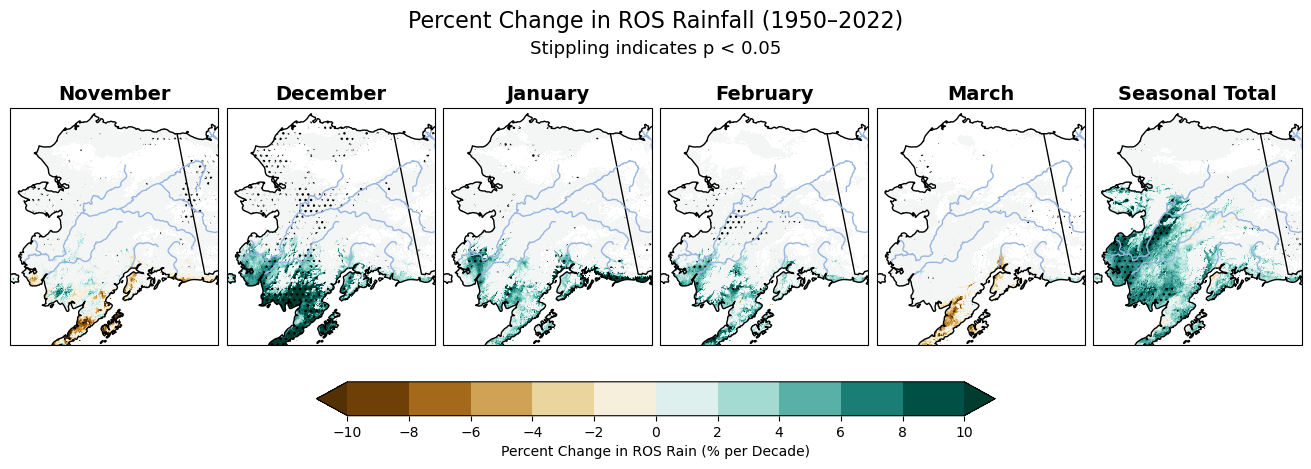

In [41]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10,10
cmap = 'BrBG'

datasets = [
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=11)*10/nov_ros_rain_sum_avg.where(nov_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=12)*10/dec_ros_rain_sum_avg.where(dec_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=1)*10/jan_ros_rain_sum_avg.where(jan_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=2)*10/feb_ros_rain_sum_avg.where(feb_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=3)*10/mar_ros_rain_sum_avg.where(mar_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_ros_sum_slope_theilsen']*10/seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold)*100, seasonal['rain_ros_sum_p_value_mannkendall'], "Seasonal Total")
]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')

fig.suptitle("Percent Change in ROS Rainfall (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Stippling indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Percent Change in ROS Rain (% per Decade)')
cbar.set_ticks(np.arange(-10, 12, 2))

fig.patch.set_alpha(0.0)
plt.show()

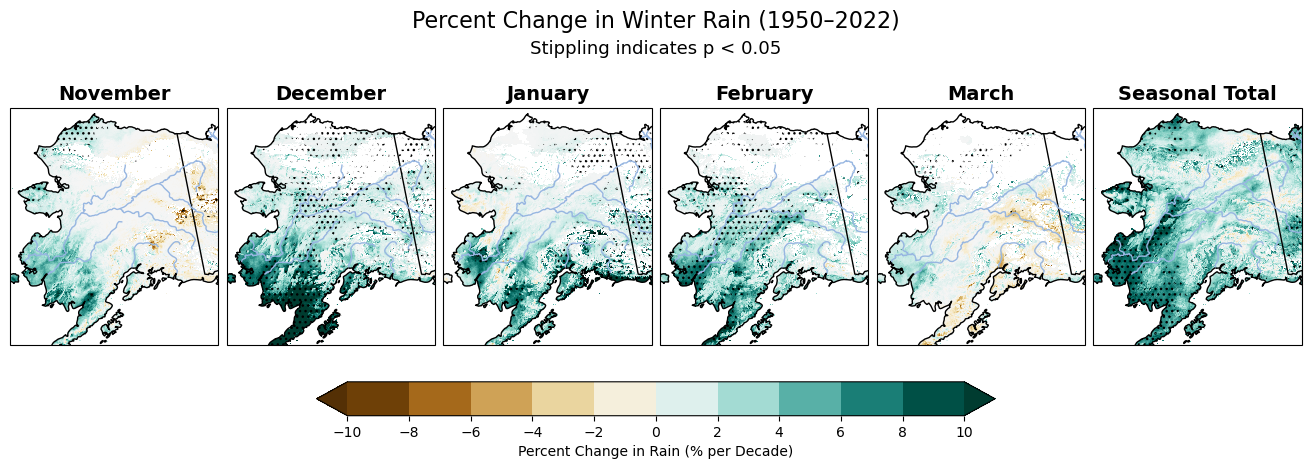

In [42]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10,10
cmap = 'BrBG'

datasets = [
    (monthly['rain_sum_slope_theilsen'].sel(month=11)*10/nov_rain_sum_avg.where(nov_rain_sum_avg > threshold_rain)*100, monthly['rain_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_sum_slope_theilsen'].sel(month=12)*10/dec_rain_sum_avg.where(dec_rain_sum_avg > threshold_rain)*100, monthly['rain_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_sum_slope_theilsen'].sel(month=1)*10/jan_rain_sum_avg.where(jan_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_sum_slope_theilsen'].sel(month=2)*10/feb_rain_sum_avg.where(feb_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_sum_slope_theilsen'].sel(month=3)*10/mar_rain_sum_avg.where(mar_rain_sum_avg > threshold_rain)*100,  monthly['rain_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_sum_slope_theilsen']*10/seasonal_rain_sum_avg.where(seasonal_rain_sum_avg > threshold_rain)*100, seasonal['rain_sum_p_value_mannkendall'], "Seasonal Total")
]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')

fig.suptitle("Percent Change in Winter Rain (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Stippling indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Percent Change in Rain (% per Decade)')
cbar.set_ticks(np.arange(-10, 12, 2))

fig.patch.set_alpha(0.0)
plt.show()

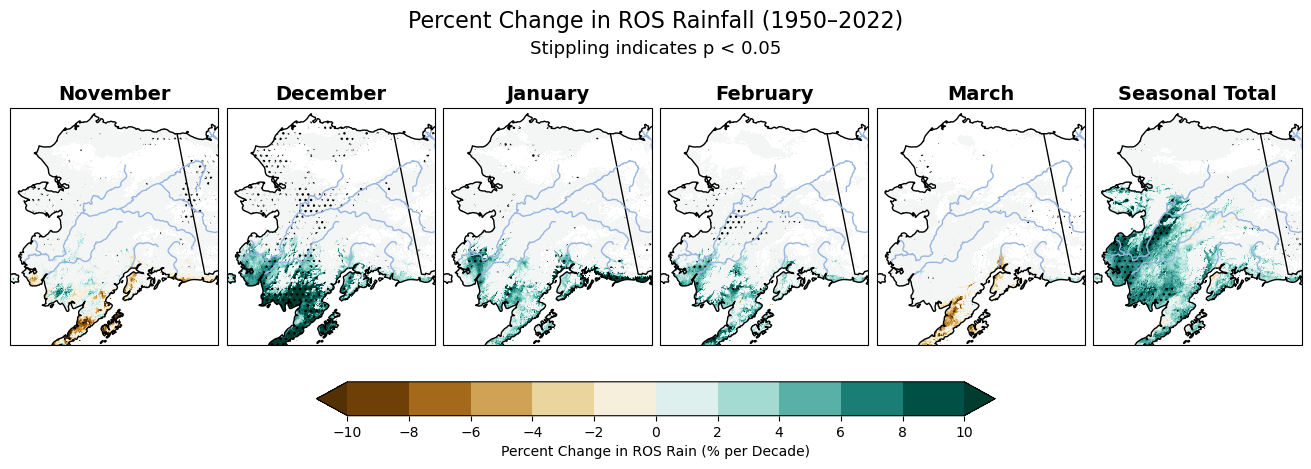

In [43]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10,10
cmap = 'BrBG'

datasets = [
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=11)*10/nov_ros_rain_sum_avg.where(nov_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=12)*10/dec_ros_rain_sum_avg.where(dec_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=1)*10/jan_ros_rain_sum_avg.where(jan_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=2)*10/feb_ros_rain_sum_avg.where(feb_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=3)*10/mar_ros_rain_sum_avg.where(mar_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_ros_sum_slope_theilsen']*10/seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold)*100, seasonal['rain_ros_sum_p_value_mannkendall'], "Seasonal Total")
]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree())
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')

fig.suptitle("Percent Change in ROS Rainfall (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Stippling indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Percent Change in ROS Rain (% per Decade)')
cbar.set_ticks(np.arange(-10, 12, 2))

fig.patch.set_alpha(0.0)
plt.show()

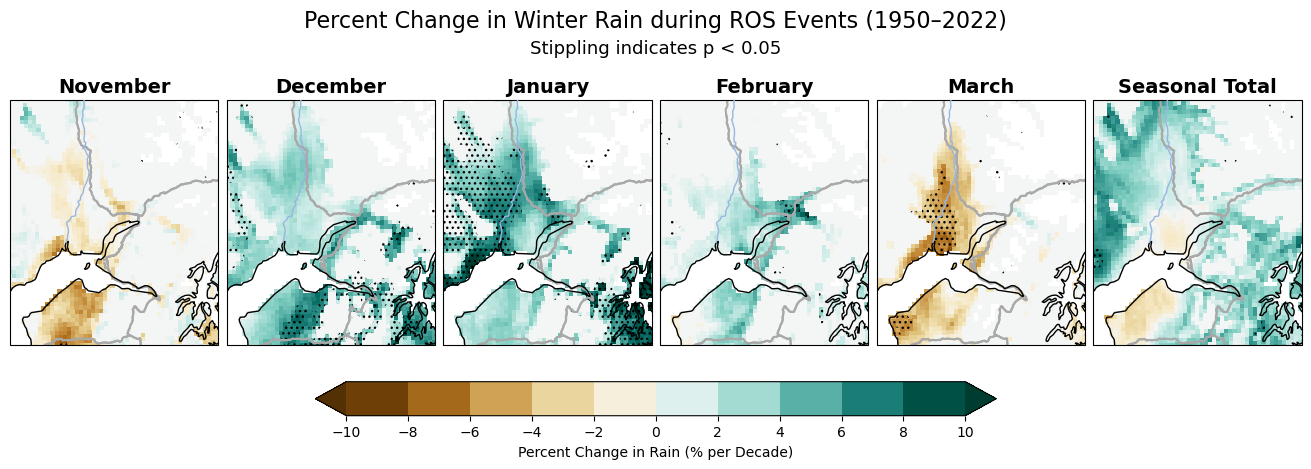

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-10, 12, 2)
vmin, vmax = -10,10
cmap = 'BrBG'

datasets = [
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=11)*10/nov_ros_rain_sum_avg.where(nov_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=12)*10/dec_ros_rain_sum_avg.where(dec_ros_rain_sum_avg > threshold)*100, monthly['rain_ros_sum_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=1)*10/jan_ros_rain_sum_avg.where(jan_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=1),  "January"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=2)*10/feb_ros_rain_sum_avg.where(feb_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=2),  "February"),
    (monthly['rain_ros_sum_slope_theilsen'].sel(month=3)*10/mar_ros_rain_sum_avg.where(mar_ros_rain_sum_avg > threshold)*100,  monthly['rain_ros_sum_p_value_mannkendall'].sel(month=3),  "March"),
    (seasonal['rain_ros_sum_slope_theilsen']*10/seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold)*100, seasonal['rain_ros_sum_p_value_mannkendall'], "Seasonal Total")
]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    
    mainroads.plot(
    ax=ax,
    facecolor='none',
    edgecolor='darkgray',
    linewidth=1.5,
    transform=ccrs.PlateCarree(),
    zorder=1,
    aspect=None   
)
    
    #ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree())
    #ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    #ax.set_aspect('equal')


fig.suptitle("Percent Change in ROS Rain (1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Stippling indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Percent Change in ROS Rain (% per Decade)')
cbar.set_ticks(np.arange(-10, 12, 2))

fig.patch.set_alpha(0.0)
plt.show()

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_2834172/941703984.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  swe_colorbar  = cm.get_cmap('BrBG', 20)
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_2834172/941703984.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rain_colorbar = cm.get_cmap('BrBG', 20)


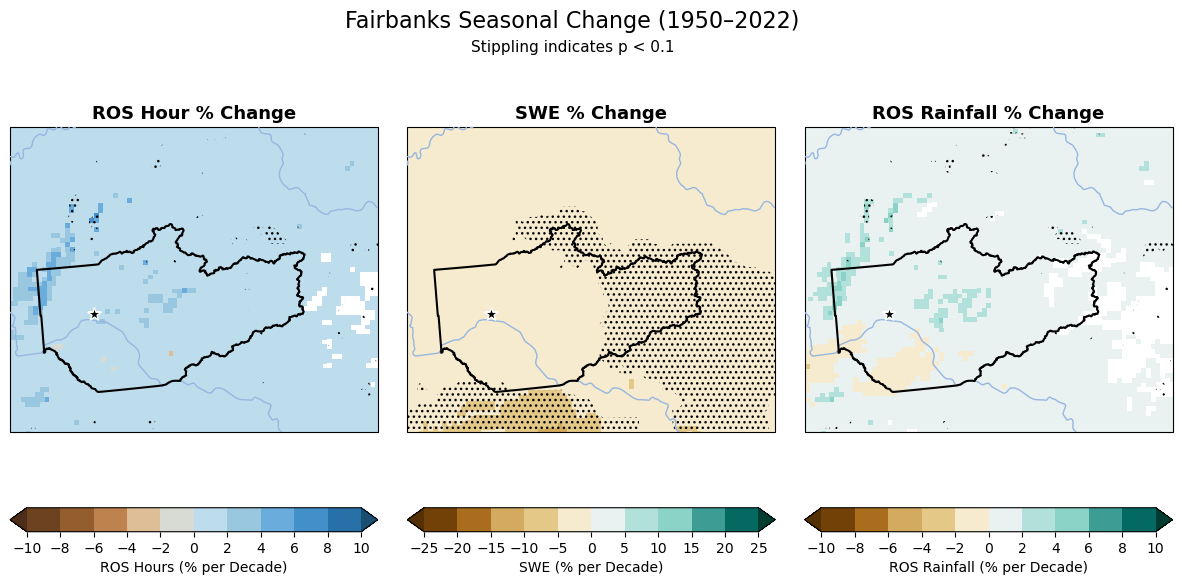

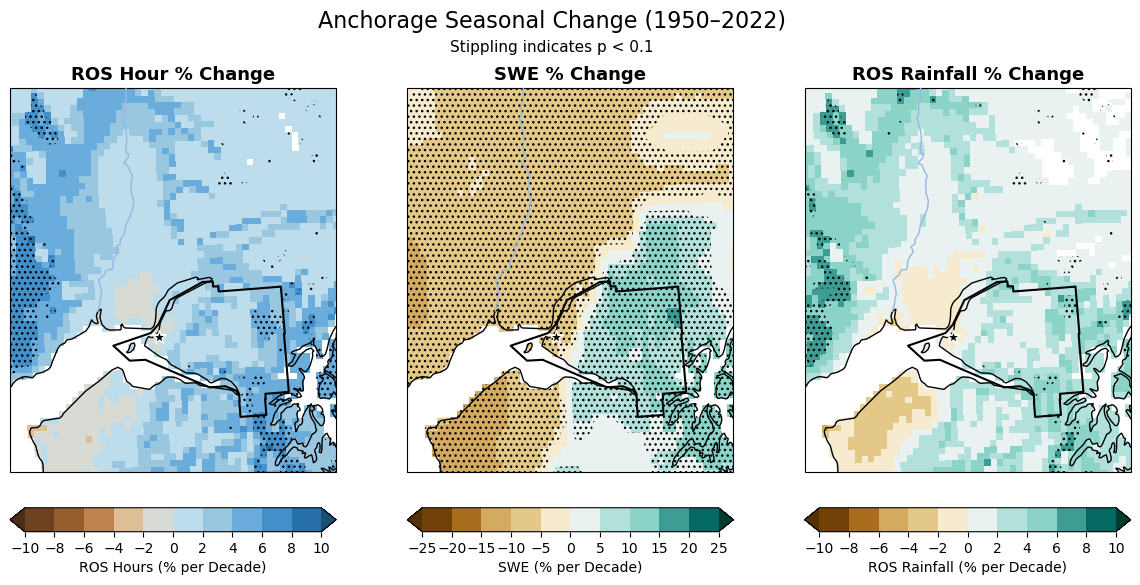

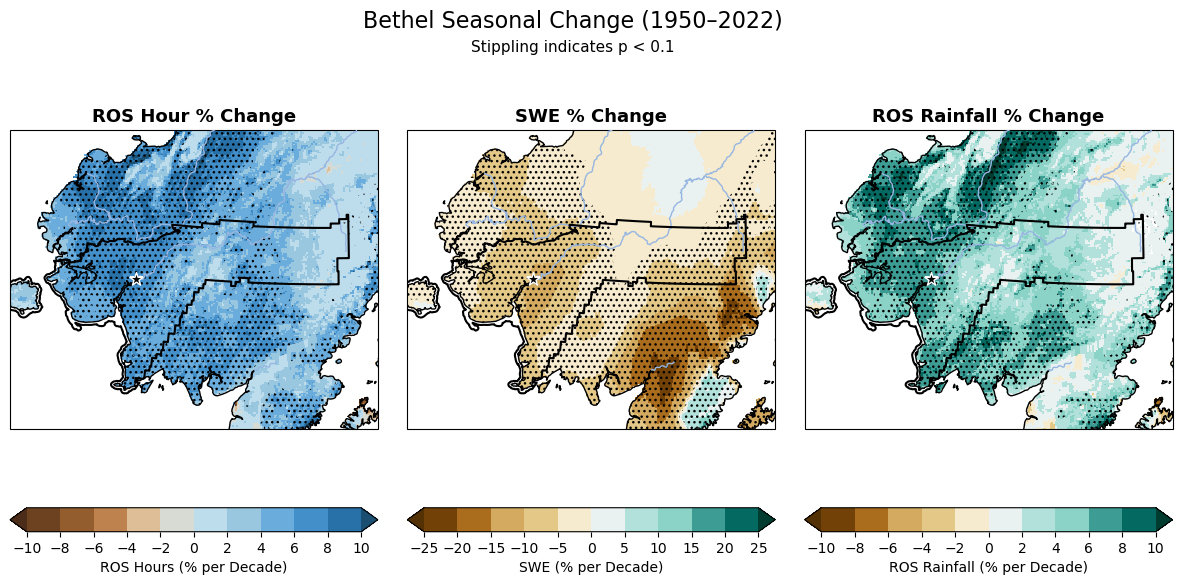

In [44]:
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

ANC_boundary = borough_boundaries[
    borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
BETHEL_boundary = borough_boundaries[
    borough_boundaries['CommunityN'] == 'Bethel Census Area']
FNSB_boundary = borough_boundaries[
    borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']

swe_colorbar  = cm.get_cmap('BrBG', 20)
rain_colorbar = cm.get_cmap('BrBG', 20)

ros_data  = (seasonal['ros_tally_slope_theilsen'] * 10 /
             seasonal_ros_tally_avg.where(seasonal_ros_tally_avg > threshold)) * 100
ros_pvals = seasonal['ros_tally_p_value_mannkendall']

rain_data  = (seasonal['rain_ros_sum_slope_theilsen'] * 10 /
              seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold_rain)) * 100
rain_pvals = seasonal['rain_ros_sum_p_value_mannkendall']

swe_data  = (seasonal['swe_avg_slope_theilsen'] * 10 /
             seasonal_swe_avg.where(seasonal_swe_avg > threshold)) * 100
swe_pvals = seasonal['swe_avg_p_value_mannkendall']

variables = [
    (ros_data,  ros_pvals,  ros_colorbar,  np.arange(-10, 12, 2), "ROS Hour % Change",        "ROS Hours (% per Decade)"),
    (swe_data,  swe_pvals,  swe_colorbar,  np.arange(-25, 30, 5), "SWE % Change",              "SWE (% per Decade)"),
    (rain_data, rain_pvals, rain_colorbar, np.arange(-10, 12, 2), "ROS Rainfall % Change", "ROS Rainfall (% per Decade)"),
]

regions = [
    ("Fairbanks", FNSB_boundary, Fairbanks_lon, Fairbanks_lat, [-149, -143, 64, 66]),
    ("Anchorage", ANC_boundary,  -149.9, 61.2,                 [-151.5, -148, 60.5, 62.5]),
    ("Bethel",    BETHEL_boundary, -161.8, 60.8,               [-166.0, -152.0, 58.0, 63.5]),
]

# ← outer loop is over REGIONS
for region_name, boundary, lon_pt, lat_pt, extent in regions:

    fig, axs = plt.subplots(
        nrows=1, ncols=3,
        figsize=(15, 6),
        subplot_kw=AK_ALBERS_SUBPLOT_KW,
        constrained_layout=False)

    plt.subplots_adjust(wspace=0.08, top=0.82, bottom=0.18)

    # ← inner loop is over VARIABLES
    for ax, (data, pvals, cmap, levels, var_label, cbar_label) in zip(axs, variables):

        norm = BoundaryNorm(levels, ncolors=cmap.N, extend='both')
        #norm = BoundaryNorm(levels, ncolors=cmap.N,clip=True)
        sig  = pvals < 0.1

        pcm = ax.pcolormesh(
            lon, lat, data,
            cmap=cmap,
            norm=norm,
            shading='auto',
            transform=ccrs.PlateCarree())

        ax.contourf(
            lon, lat, sig,
            levels=[0.5, 1.5],
            colors='none',
            hatches=['...'],
            transform=ccrs.PlateCarree())

        ax.set_extent(extent, crs=ccrs.PlateCarree())

        boundary.plot(
            ax=ax,
            facecolor='none',
            edgecolor='black',
            linewidth=1.5,
            transform=ccrs.PlateCarree(),
            zorder=5)

        ax.scatter(
            lon_pt, lat_pt,
            marker='*',
            facecolors='black',
            edgecolors='white',
            linewidths=1.0,
            s=100,
            zorder=6,
            transform=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, zorder=3)
        ax.add_feature(cfeature.RIVERS,    zorder=3)
        ax.set_facecolor('white')
        ax.set_aspect('equal')
        ax.set_title(var_label, fontsize=13, fontweight='bold')

        fig.canvas.draw()

        pos = ax.get_position()
        cbar_ax = fig.add_axes([pos.x0, 0.08, pos.width, 0.04])
        cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal',
                            boundaries=levels, ticks=levels, extend='both')
        cbar.set_label(cbar_label, fontsize=10)

    fig.suptitle(f"{region_name} Seasonal Change (1950–2022)", fontsize=16, y=0.95)
    fig.text(0.5, 0.88, "Stippling indicates p < 0.1", ha='center', fontsize=11)
    fig.patch.set_alpha(0.0)

    plt.show()

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_2834172/3838291148.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  swe_colorbar  = cm.get_cmap('BrBG', 20)
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_2834172/3838291148.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rain_colorbar = cm.get_cmap('BrBG', 20)


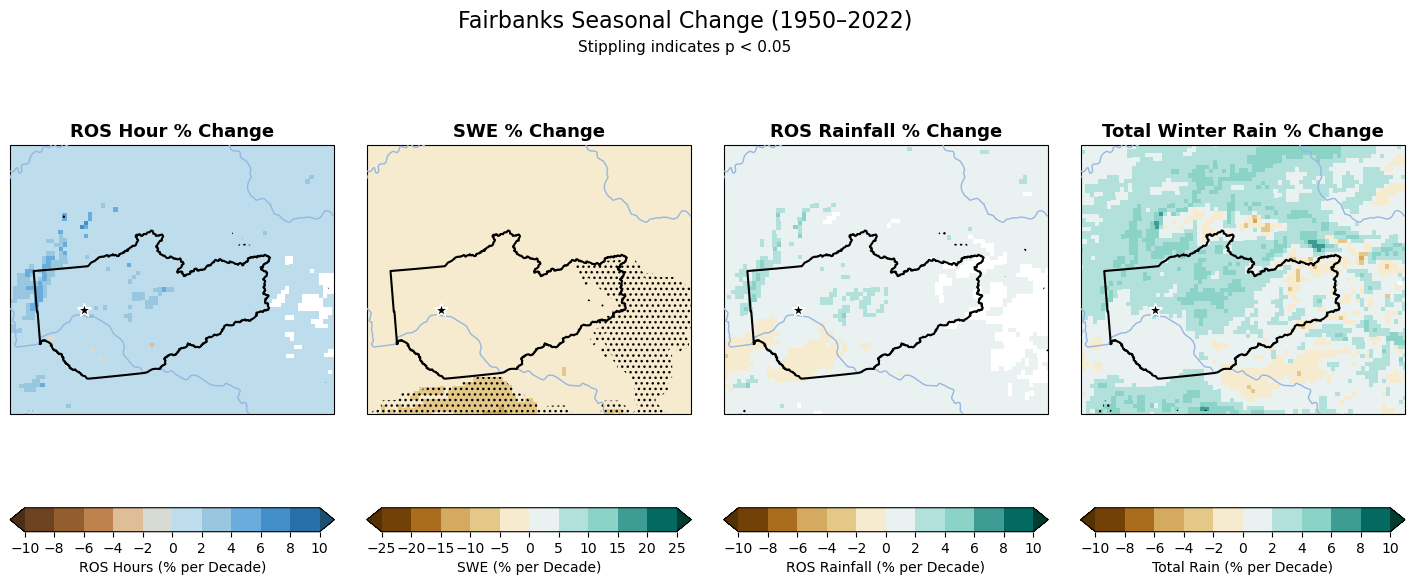

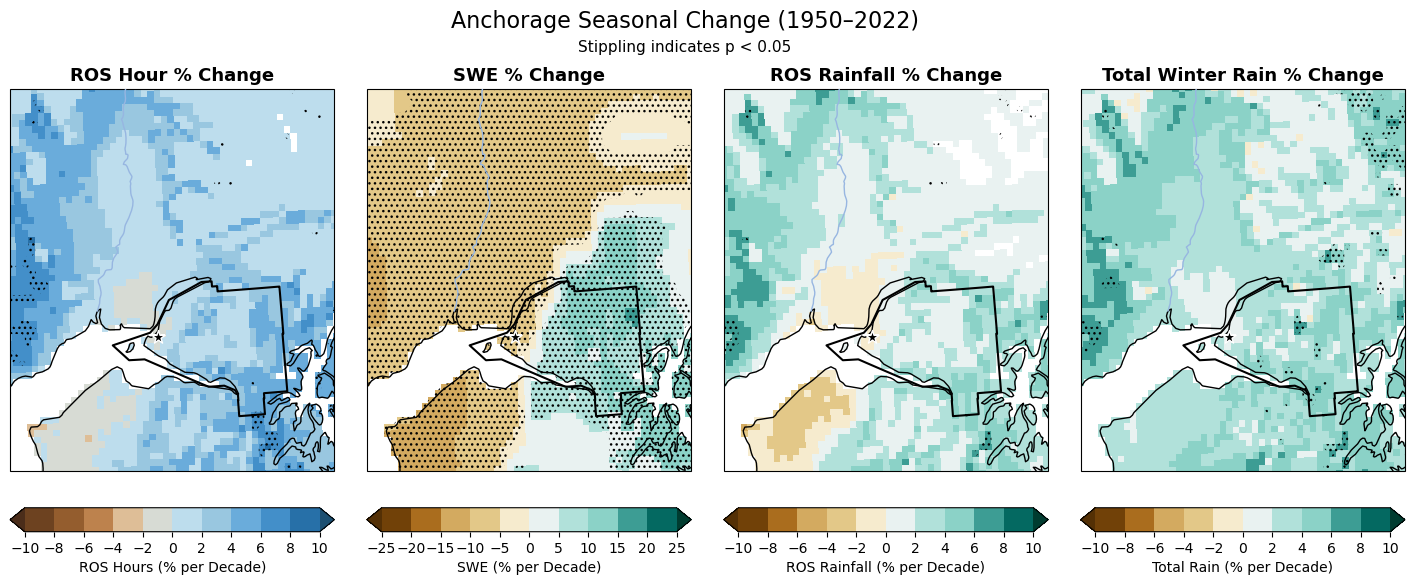

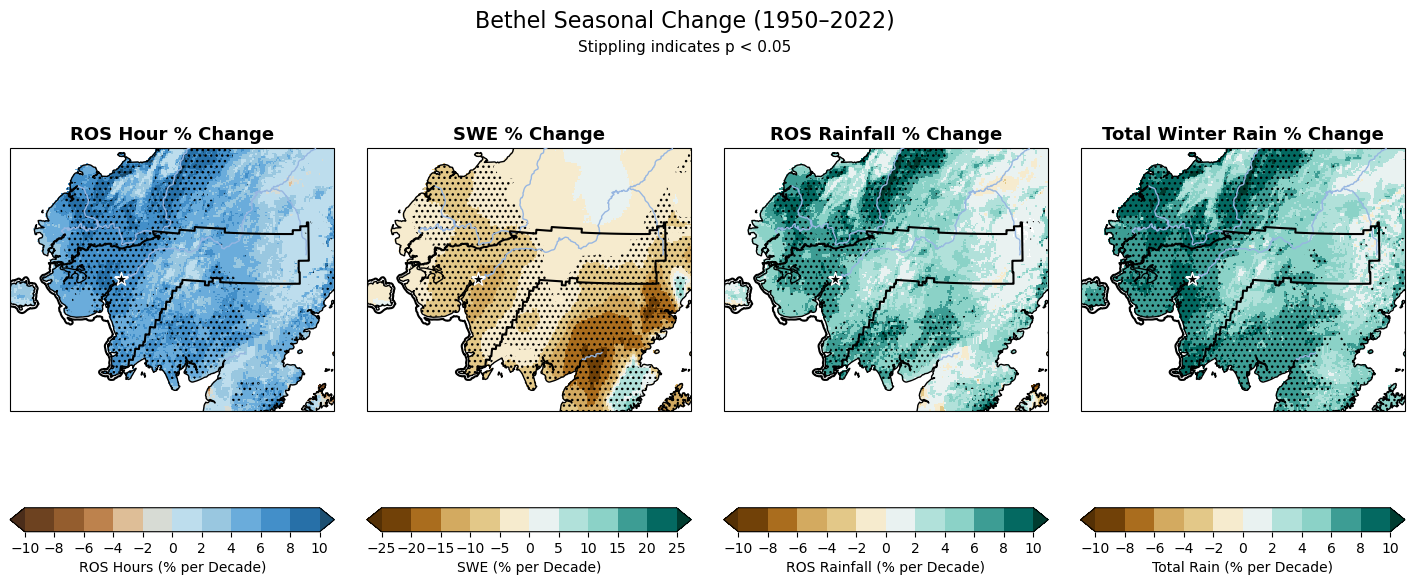

In [45]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

ANC_boundary = borough_boundaries[
    borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
BETHEL_boundary = borough_boundaries[
    borough_boundaries['CommunityN'] == 'Bethel Census Area']
FNSB_boundary = borough_boundaries[
    borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']


swe_colorbar  = cm.get_cmap('BrBG', 20)
rain_colorbar = cm.get_cmap('BrBG', 20)

ros_data  = (seasonal['ros_tally_slope_theilsen'] * 10 /
             seasonal_ros_tally_avg.where(seasonal_ros_tally_avg > threshold)) * 100
ros_pvals = seasonal['ros_tally_p_value_mannkendall']


swe_data  = (seasonal['swe_avg_slope_theilsen'] * 10 /
             seasonal_swe_avg.where(seasonal_swe_avg > threshold)) * 100
swe_pvals = seasonal['swe_avg_p_value_mannkendall']

rain_data  = (seasonal['rain_ros_sum_slope_theilsen'] * 10 /
              seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold_rain)) * 100
rain_pvals = seasonal['rain_ros_sum_p_value_mannkendall']


winter_rain_data = (seasonal['rain_sum_slope_theilsen'] * 10 /
                    seasonal_rain_sum_avg.where(seasonal_rain_sum_avg > threshold_rain)) * 100
winter_rain_pvals = seasonal['rain_sum_p_value_mannkendall']


variables = [
    (ros_data,  ros_pvals,  ros_colorbar, np.arange(-10, 12, 2), "ROS Hour % Change",        "ROS Hours (% per Decade)"),
    (swe_data,  swe_pvals,  swe_colorbar,  np.arange(-25, 30, 5), "SWE % Change",              "SWE (% per Decade)"),
    (rain_data, rain_pvals, rain_colorbar, np.arange(-10, 12, 2), "ROS Rainfall % Change", "ROS Rainfall (% per Decade)"),
    (winter_rain_data, winter_rain_pvals, rain_colorbar, np.arange(-10, 12, 2), "Total Winter Rain % Change", "Total Rain (% per Decade)")
]


regions = [
    ("Fairbanks", FNSB_boundary, Fairbanks_lon, Fairbanks_lat, [-149, -143, 64, 66]),
    ("Anchorage", ANC_boundary,  -149.9, 61.2,                 [-151.5, -148, 60.5, 62.5]),
    ("Bethel",    BETHEL_boundary, -161.8, 60.8,               [-166.0, -152.0, 58.0, 63.5]),
]

for region_name, boundary, lon_pt, lat_pt, extent in regions:

    fig, axs = plt.subplots(
        nrows=1, ncols=4,   # ← updated to 4 panels
        figsize=(18, 6),
        subplot_kw=AK_ALBERS_SUBPLOT_KW,
        constrained_layout=False)

    plt.subplots_adjust(wspace=0.1, top=0.82, bottom=0.18)

    for ax, (data, pvals, cmap, levels, var_label, cbar_label) in zip(axs, variables):

        norm = BoundaryNorm(levels, ncolors=cmap.N, extend='both')
        #clip=True)
        sig  = pvals < 0.05

        pcm = ax.pcolormesh(
            lon, lat, data,
            cmap=cmap,
            norm=norm,
            shading='auto',
            transform=ccrs.PlateCarree())

        ax.contourf(
            lon, lat, sig,
            levels=[0.5, 1.5],
            colors='none',
            hatches=['...'],
            transform=ccrs.PlateCarree())

        ax.set_extent(extent, crs=ccrs.PlateCarree())

        boundary.plot(
            ax=ax,
            facecolor='none',
            edgecolor='black',
            linewidth=1.5,
            transform=ccrs.PlateCarree(),
            zorder=5)

        ax.scatter(
            lon_pt, lat_pt,
            marker='*',
            facecolors='black',
            edgecolors='white',
            linewidths=1.0,
            s=100,
            zorder=6,
            transform=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, zorder=3)
        ax.add_feature(cfeature.RIVERS,    zorder=3)
        ax.set_facecolor('white')
        ax.set_aspect('equal')
        ax.set_title(var_label, fontsize=13, fontweight='bold')
        
        fig.canvas.draw()
        pos = ax.get_position()

        cbar_ax = fig.add_axes([pos.x0, 0.08, pos.width, 0.04])
        cbar = fig.colorbar(
            pcm,
            cax=cbar_ax,
            orientation='horizontal',
            boundaries=levels,
            ticks=levels,
            extend='both'
        )
        cbar.set_label(cbar_label, fontsize=10)

    fig.suptitle(f"{region_name} Seasonal Change (1950–2022)", fontsize=16, y=0.95)
    fig.text(0.5, 0.88, "Stippling indicates p < 0.05", ha='center', fontsize=11)
    fig.patch.set_alpha(0.0)

    plt.show()

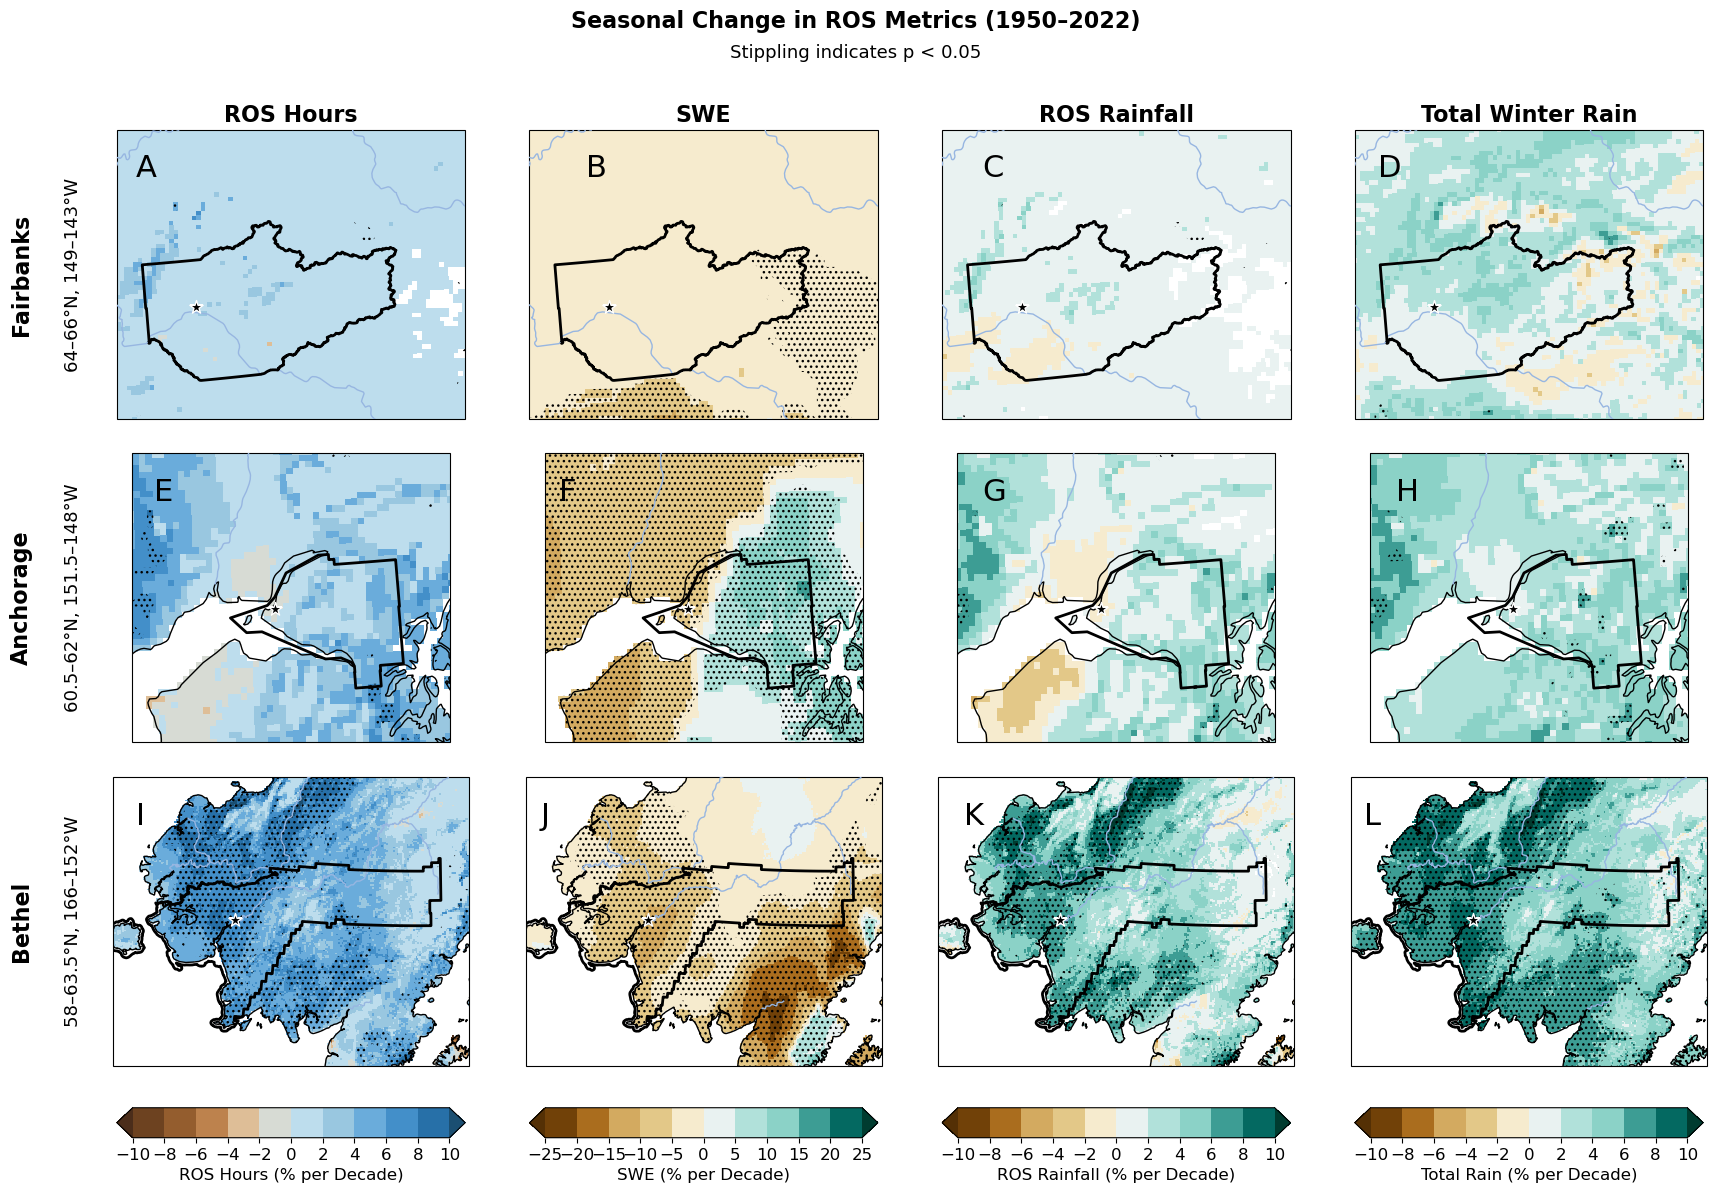

In [52]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import BoundaryNorm
from matplotlib import cm

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

variables = [
    (ros_data,  ros_pvals,  ros_colorbar,  np.arange(-10, 12, 2),  "ROS Hours",        "ROS Hours (% per Decade)"),
    (swe_data,  swe_pvals,  swe_colorbar,  np.arange(-25, 30, 5),  "SWE",              "SWE (% per Decade)"),
    (rain_data, rain_pvals, rain_colorbar, np.arange(-10, 12, 2),  "ROS Rainfall",  "ROS Rainfall (% per Decade)"),
    (winter_rain_data, winter_rain_pvals, rain_colorbar, np.arange(-10, 12, 2), "Total Winter Rain", "Total Rain (% per Decade)")
]

regions = [
    ("Fairbanks", "64–66°N, 149–143°W",   FNSB_boundary,   Fairbanks_lon, Fairbanks_lat, [-149,   -143,  64,   66  ]),
    ("Anchorage", "60.5–62°N, 151.5–148°W", ANC_boundary,   -149.9,         61.2,          [-151.5, -148,  60.5, 62  ]),
    ("Bethel",    "58–63.5°N, 166–152°W",  BETHEL_boundary, -161.8,         60.8,          [-166.0, -152.0, 58.0, 63.5]),
]

n_rows = len(regions)    # 3
n_cols = len(variables)  # 4

fig, axs = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(18, 12),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=False)

plt.subplots_adjust(
    left=0.08, right=0.98,
    top=0.92,  bottom=0.14,
    wspace=0.08, hspace=0.12)

pcm_per_col = {}

for row_idx, (region_name, extent_label, boundary, lon_pt, lat_pt, extent) in enumerate(regions):
    for col_idx, (data, pvals, cmap, levels, var_label, cbar_label) in enumerate(variables):

        ax = axs[row_idx, col_idx]
        norm = BoundaryNorm(levels, ncolors=cmap.N, extend='both')
        sig  = pvals < 0.05

        pcm = ax.pcolormesh(
            lon, lat, data,
            cmap=cmap, norm=norm,
            shading='auto',
            transform=ccrs.PlateCarree())

        ax.contourf(
            lon, lat, sig,
            levels=[0.5, 1.5],
            colors='none', hatches=['...'],
            transform=ccrs.PlateCarree())

        ax.set_extent(extent, crs=ccrs.PlateCarree())

        boundary.plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=2, transform=ccrs.PlateCarree(), zorder=5)

        ax.scatter(
            lon_pt, lat_pt,
            marker='*', facecolors='black', edgecolors='white',
            linewidths=1.0, s=100, zorder=6,
            transform=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, zorder=3)
        ax.add_feature(cfeature.RIVERS,    zorder=3)
        ax.set_facecolor('white')
        ax.set_aspect('equal')

        # Column headers (top row only)
        if row_idx == 0:
            ax.set_title(var_label, fontsize=16, fontweight='bold', pad=6)

        # Row labels (first column only)
        if col_idx == 0:
            fig.canvas.draw()
            pos = ax.get_position()
            cy = pos.y0 + pos.height / 2
            fig.text(
                0.03, cy,
                region_name,
                fontsize=16, fontweight='bold',
                ha='left', va='center',
                rotation=90)
            fig.text(
                0.06, cy,
                extent_label,
                fontsize=13,
                ha='left', va='center',
                rotation=90,
                color='black')
        if row_idx == 0:
            pcm_per_col[col_idx] = (pcm, levels, cbar_label)

fig.canvas.draw()

for col_idx, (pcm, levels, cbar_label) in pcm_per_col.items():
    pos = axs[0, col_idx].get_position()

    cbar_ax = fig.add_axes([
        pos.x0,
        0.08,
        pos.width,
        0.025
    ])
    cbar = fig.colorbar(
        pcm, cax=cbar_ax,
        orientation='horizontal',
        extend='both',
        ticks=levels)
    cbar.set_label(cbar_label, fontsize=12)
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

fig.suptitle("Seasonal Change in ROS Metrics (1950–2022)", fontsize=16, fontweight='bold', y=1.02)
fig.text(0.5, 0.98, "Stippling indicates p < 0.05",
         ha='center', fontsize=13, color='black')

#fig.text(0.005, 0.91, 'A', fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.1, 0.90, 'A', fontsize=22, va='top', ha='left')
fig.text(0.35, 0.90, 'B', fontsize=22, va='top', ha='left')
fig.text(0.57, 0.90, 'C', fontsize=22, va='top', ha='left')
fig.text(0.79, 0.90, 'D', fontsize=22, va='top', ha='left')

fig.text(0.11, 0.63, 'E', fontsize=22, va='top', ha='left')
fig.text(0.335, 0.63, 'F', fontsize=22, va='top', ha='left')
fig.text(0.57, 0.63, 'G', fontsize=22, va='top', ha='left')
fig.text(0.8, 0.63, 'H', fontsize=22, va='top', ha='left')

fig.text(0.1, 0.36, 'I', fontsize=22,  va='top', ha='left')
fig.text(0.325, 0.36, 'J', fontsize=22,  va='top', ha='left')
fig.text(0.56, 0.36, 'K', fontsize=22,  va='top', ha='left')
fig.text(0.782, 0.36, 'L', fontsize=22,  va='top', ha='left')


fig.patch.set_alpha(0.0)
plt.show()

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_3103842/3702867135.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  swe_colorbar  = cm.get_cmap('BrBG', 20)
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_3103842/3702867135.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rain_colorbar = cm.get_cmap('BrBG', 20)


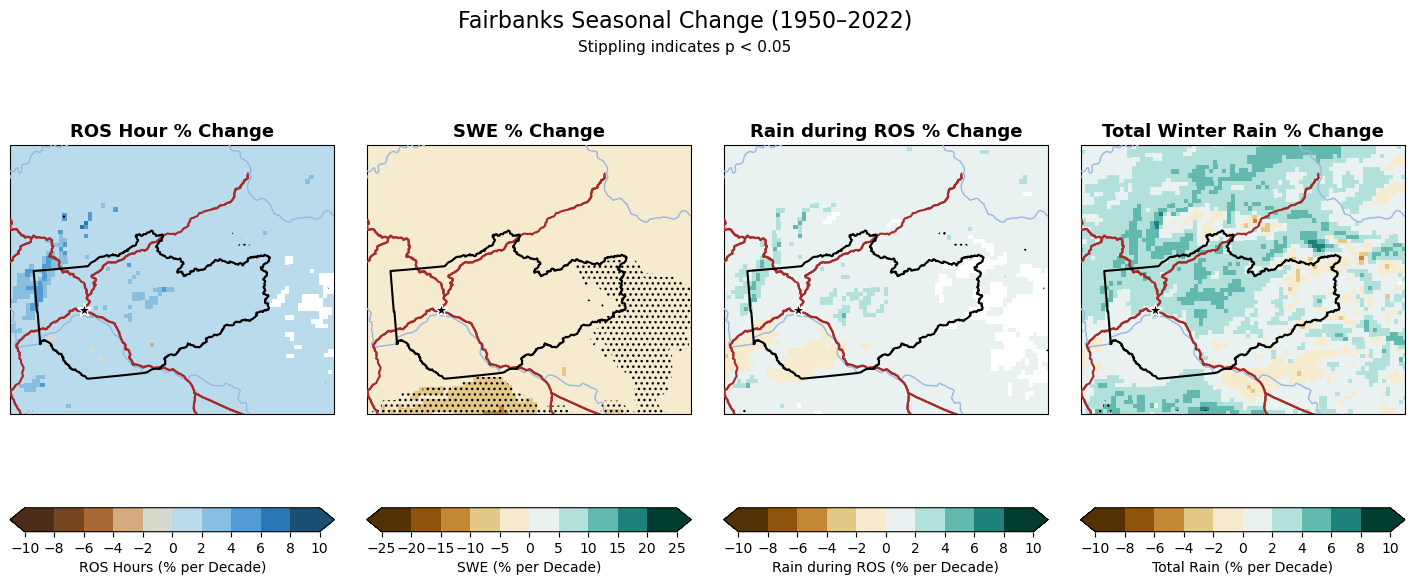

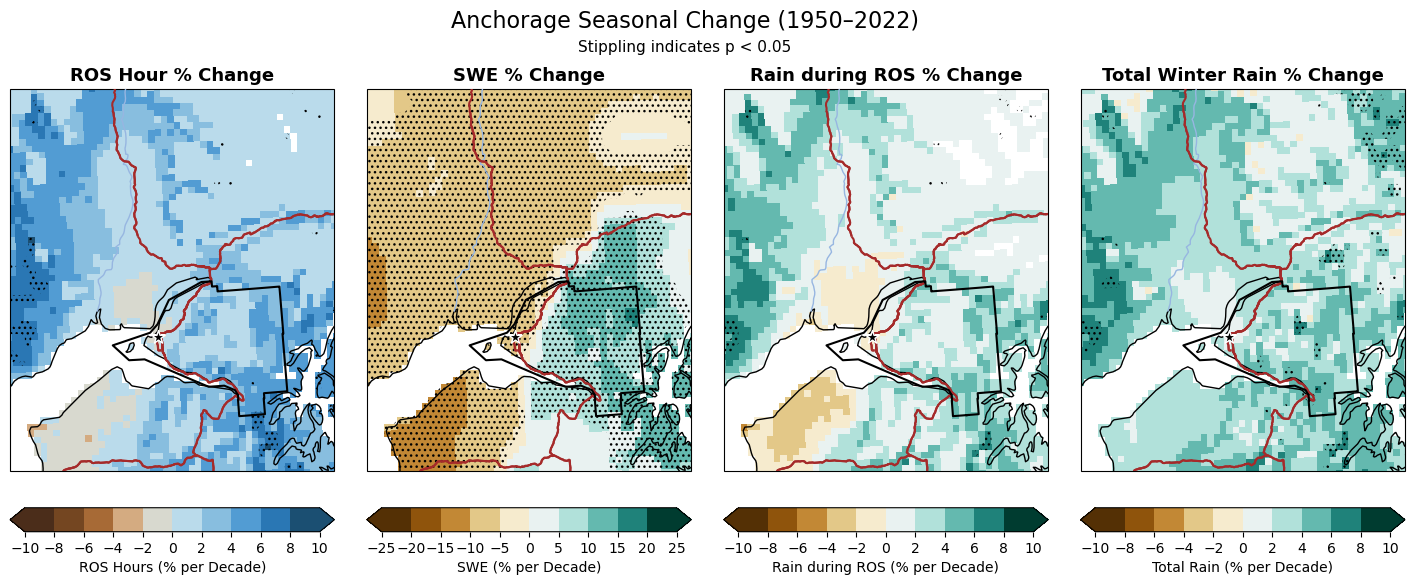

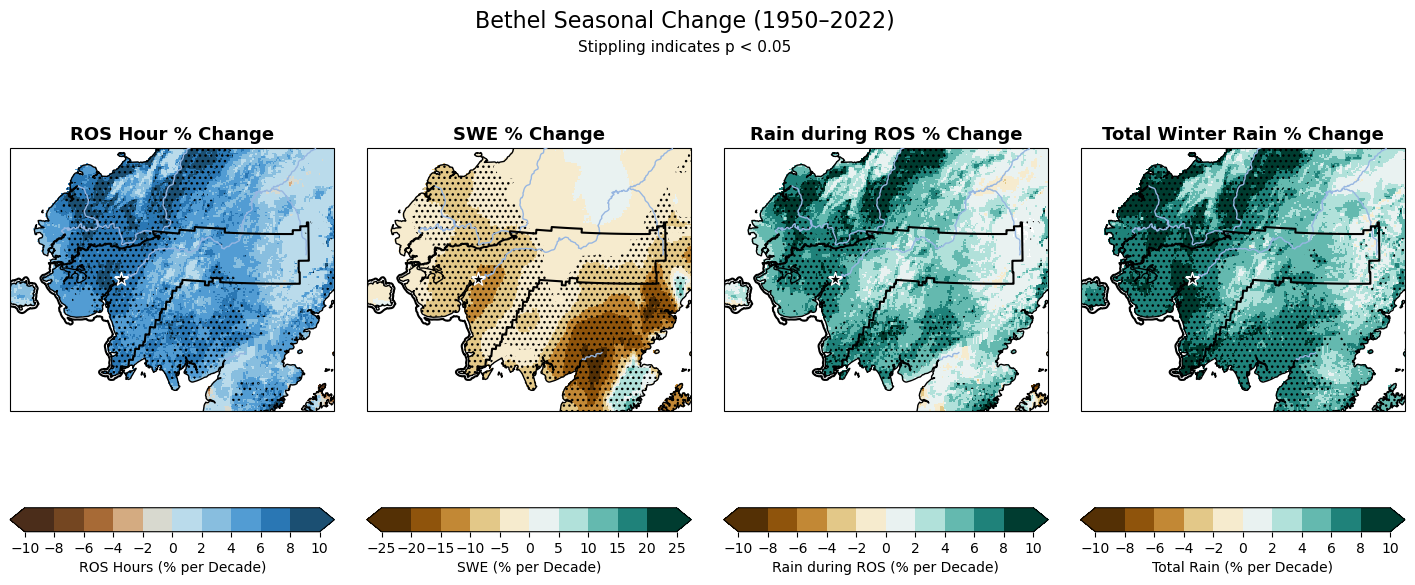

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

ANC_boundary = borough_boundaries[
    borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
BETHEL_boundary = borough_boundaries[
    borough_boundaries['CommunityN'] == 'Bethel Census Area']
FNSB_boundary = borough_boundaries[
    borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']

swe_colorbar  = cm.get_cmap('BrBG', 20)
rain_colorbar = cm.get_cmap('BrBG', 20)

ros_data  = (seasonal['ros_tally_slope_theilsen'] * 10 /
             seasonal_ros_tally_avg.where(seasonal_ros_tally_avg > threshold)) * 100
ros_pvals = seasonal['ros_tally_p_value_mannkendall']


swe_data  = (seasonal['swe_avg_slope_theilsen'] * 10 /
             seasonal_swe_avg.where(seasonal_swe_avg > threshold)) * 100
swe_pvals = seasonal['swe_avg_p_value_mannkendall']

rain_data  = (seasonal['rain_ros_sum_slope_theilsen'] * 10 /
              seasonal_ros_rain_sum_avg.where(seasonal_ros_rain_sum_avg > threshold_rain)) * 100
rain_pvals = seasonal['rain_ros_sum_p_value_mannkendall']


winter_rain_data = (seasonal['rain_sum_slope_theilsen'] * 10 /
                    seasonal_rain_sum_avg.where(seasonal_rain_sum_avg > threshold_rain)) * 100
winter_rain_pvals = seasonal['rain_sum_p_value_mannkendall']


variables = [
    (ros_data,  ros_pvals,  ros_colorbar, np.arange(-10, 12, 2), "ROS Hour % Change",        "ROS Hours (% per Decade)"),
    (swe_data,  swe_pvals,  swe_colorbar,  np.arange(-25, 30, 5), "SWE % Change",              "SWE (% per Decade)"),
    (rain_data, rain_pvals, rain_colorbar, np.arange(-10, 12, 2), "Rain during ROS % Change", "Rain during ROS (% per Decade)"),
    (winter_rain_data, winter_rain_pvals, rain_colorbar, np.arange(-10, 12, 2), "Total Winter Rain % Change", "Total Rain (% per Decade)")
]


regions = [
    ("Fairbanks", FNSB_boundary, Fairbanks_lon, Fairbanks_lat, [-149, -143, 64, 66]),
    ("Anchorage", ANC_boundary,  -149.9, 61.2,                 [-151.5, -148, 60.5, 62.5]),
    ("Bethel",    BETHEL_boundary, -161.8, 60.8,               [-166.0, -152.0, 58.0, 63.5]),
]

for region_name, boundary, lon_pt, lat_pt, extent in regions:

    fig, axs = plt.subplots(
        nrows=1, ncols=4,   # ← updated to 4 panels
        figsize=(18, 6),
        subplot_kw=AK_ALBERS_SUBPLOT_KW,
        constrained_layout=False)

    plt.subplots_adjust(wspace=0.1, top=0.82, bottom=0.18)

    for ax, (data, pvals, cmap, levels, var_label, cbar_label) in zip(axs, variables):

        norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
        sig  = pvals < 0.05

        pcm = ax.pcolormesh(
            lon, lat, data,
            cmap=cmap,
            norm=norm,
            shading='auto',
            transform=ccrs.PlateCarree())

        ax.contourf(
            lon, lat, sig,
            levels=[0.5, 1.5],
            colors='none',
            hatches=['...'],
            transform=ccrs.PlateCarree())

        ax.set_extent(extent, crs=ccrs.PlateCarree())

        boundary.plot(
            ax=ax,
            facecolor='none',
            edgecolor='black',
            linewidth=1.5,
            transform=ccrs.PlateCarree(),
            zorder=5)
        
        mainroads.plot(
            ax=ax,
            facecolor='none',
            edgecolor='brown',
            linewidth=1.5,
            transform=ccrs.PlateCarree(),
            zorder=4) 
        
        ax.scatter(
            lon_pt, lat_pt,
            marker='*',
            facecolors='black',
            edgecolors='white',
            linewidths=1.0,
            s=100,
            zorder=6,
            transform=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, zorder=3)
        ax.add_feature(cfeature.RIVERS,    zorder=3)
        ax.set_facecolor('white')
        ax.set_aspect('equal')
        ax.set_title(var_label, fontsize=13, fontweight='bold')
        
        fig.canvas.draw()
        pos = ax.get_position()

        cbar_ax = fig.add_axes([pos.x0, 0.08, pos.width, 0.04])
        cbar = fig.colorbar(
            pcm,
            cax=cbar_ax,
            orientation='horizontal',
            boundaries=levels,
            ticks=levels,
            extend='both'
        )
        cbar.set_label(cbar_label, fontsize=10)

    fig.suptitle(f"{region_name} Seasonal Change (1950–2022)", fontsize=16, y=0.95)
    fig.text(0.5, 0.88, "Stippling indicates p < 0.05", ha='center', fontsize=11)
    fig.patch.set_alpha(0.0)

    plt.show()

In [41]:
nov_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=11),axis=0)
dec_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=12),axis=0)
jan_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=1),axis=0)
feb_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=2),axis=0)
mar_t2_avg=np.mean(combined_ds['T2_avg'].sel(month=3),axis=0)
seasonal_t2_avg=np.mean(combined_ds['T2_avg'].sum(axis=1),axis=0)

nov_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=11),axis=0)
dec_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=12),axis=0)
jan_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=1),axis=0)
feb_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=2),axis=0)
mar_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sel(month=3),axis=0)
seasonal_t2_ros_avg=np.mean(combined_ds['T2_ros_avg'].sum(axis=1),axis=0)

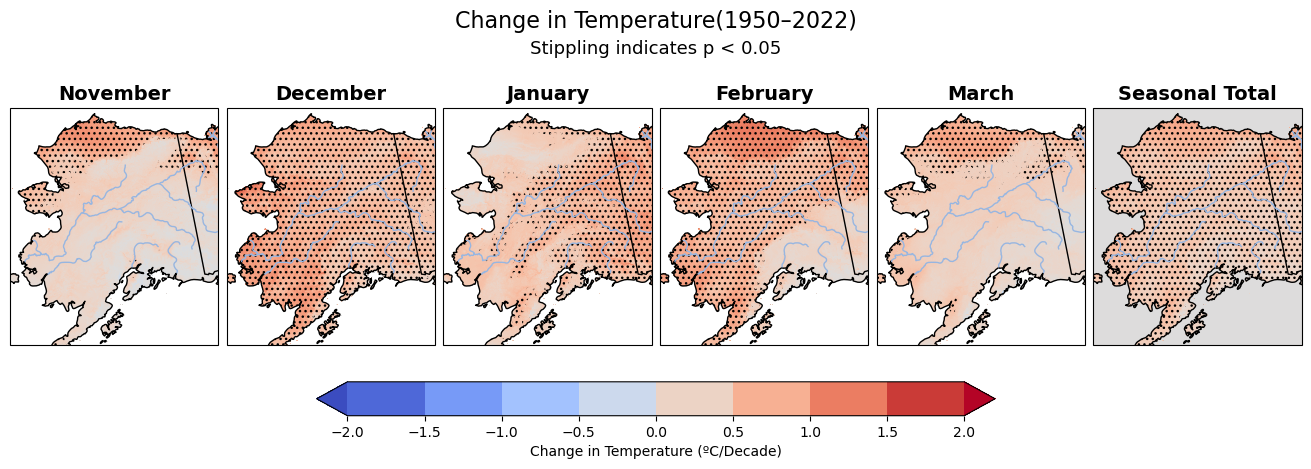

In [42]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}
fig, axs = plt.subplots(
    nrows=1, ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True)
levels=np.arange(-2, 2.5, .5)
vmin, vmax = -2,2
cmap = 'coolwarm'

datasets = [
    (monthly['T2_avg_slope_theilsen'].sel(month=11)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=11), "November"),
    (monthly['T2_avg_slope_theilsen'].sel(month=12)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=12), "December"),
    (monthly['T2_avg_slope_theilsen'].sel(month=1)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=1), "January"),
    (monthly['T2_avg_slope_theilsen'].sel(month=2)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=2), "February"),
    (monthly['T2_avg_slope_theilsen'].sel(month=3)*10,monthly['T2_avg_p_value_mannkendall'].sel(month=3), "March"),
    (((seasonal['T2_avg_slope_theilsen'])/5)*10,seasonal['T2_avg_p_value_mannkendall'],"Seasonal Total")]

for ax, (data,pvals,title) in zip(axs, datasets):
    pcm = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree())
    sig = pvals < 0.05

    ax.contourf(
        lon, lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )
    
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    #ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')

fig.suptitle("Change in Temperature(1950–2022)",fontsize=16, y=0.83)
fig.text(0.5, 0.75, "Stippling indicates p < 0.05",ha='center',fontsize=13)
cbar = fig.colorbar(pcm, ax=axs,boundaries=levels,orientation='horizontal',fraction=0.08, pad=0.08,extend='both')
cbar.set_label(r'Change in Temperature (ºC/Decade)')
cbar.set_ticks(np.arange(-2, 2.5, .5))

fig.patch.set_alpha(0.0)
plt.show()
